ECHOZERO — DECISION INTELLIGENCE ENGINE

DATASET OVERVIEW
---------------------------------------------------------------------------
Rows: 1200
Columns: 18

Missing values:
0

Duplicate rows:
0

Data types:
Date                     datetime64[ns]
Evidence                        float64
Skill                           float64
Uncertainty                     float64
Experimentation                 float64
Reward                          float64
Risk                            float64
Confidence                      float64
True_Probability                float64
Predicted_Probability           float64
Outcome                           int64
Decision_Quality                float64
Execution_Delay                 float64
Expected_Value                  float64
Actual_Value                    float64
Prediction_Error                float64
Absolute_Error                  float64
Correct_Prediction                int64
dtype: object


EXECUTIVE KPIs
Decision Health       : 50.01%
Average Co

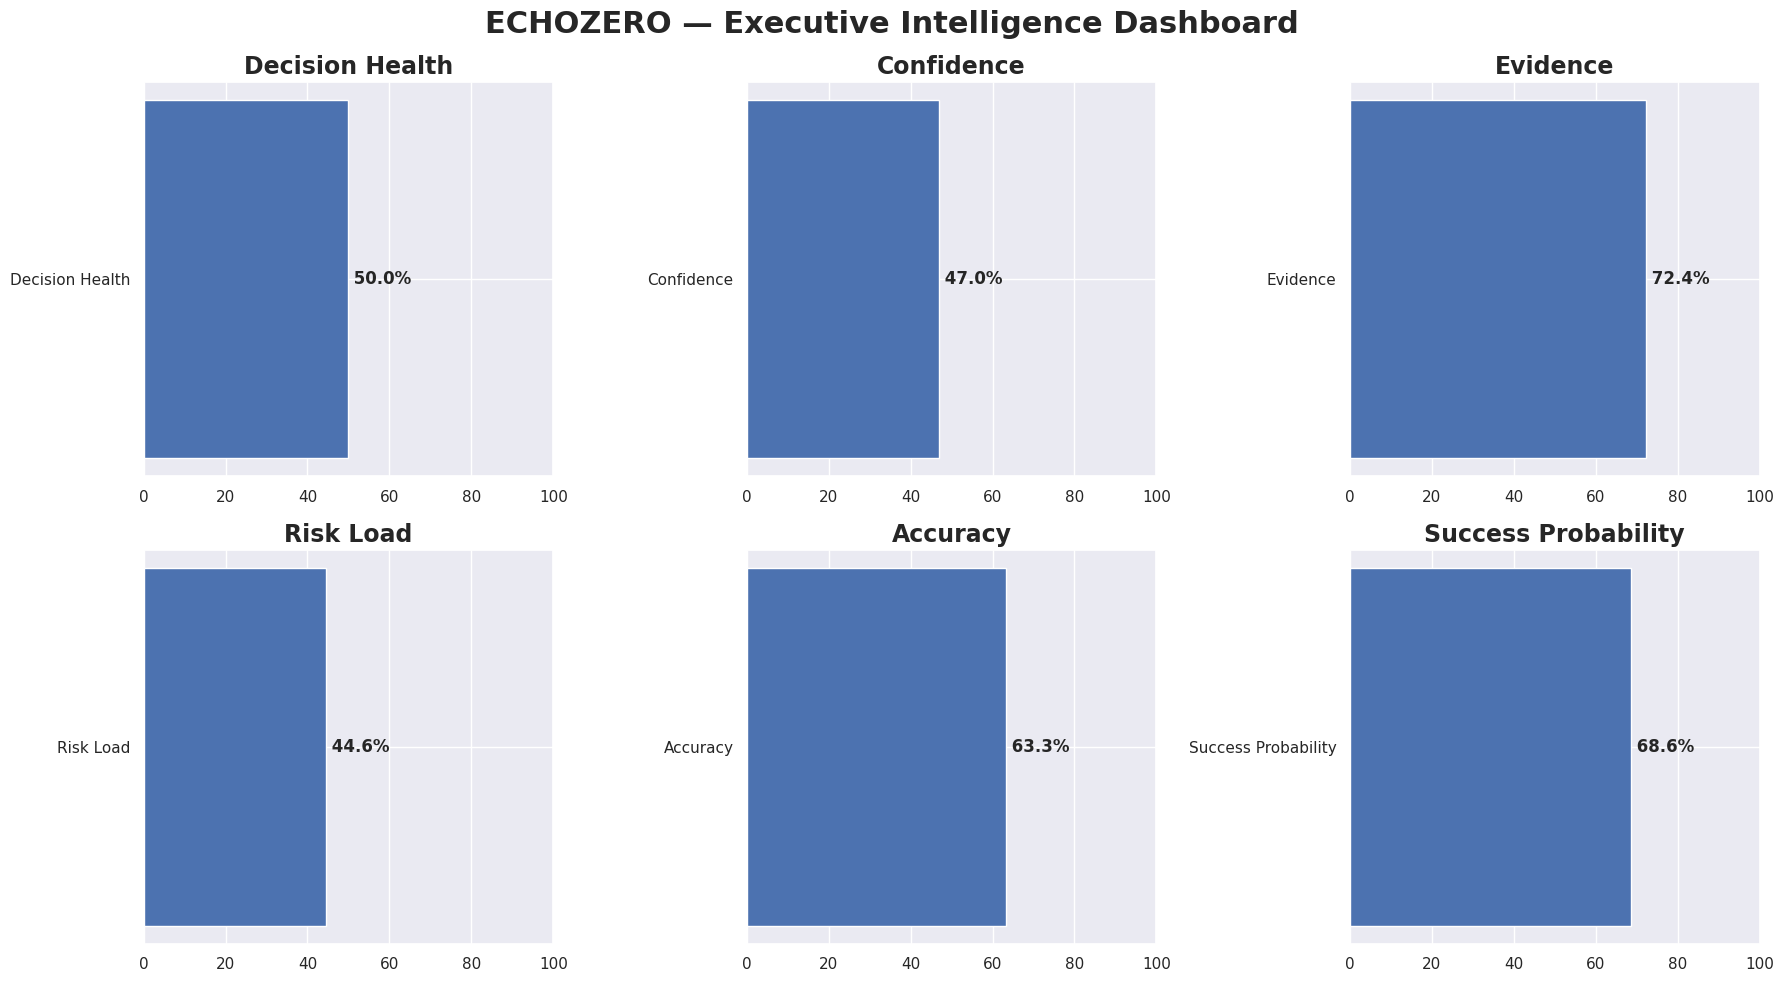

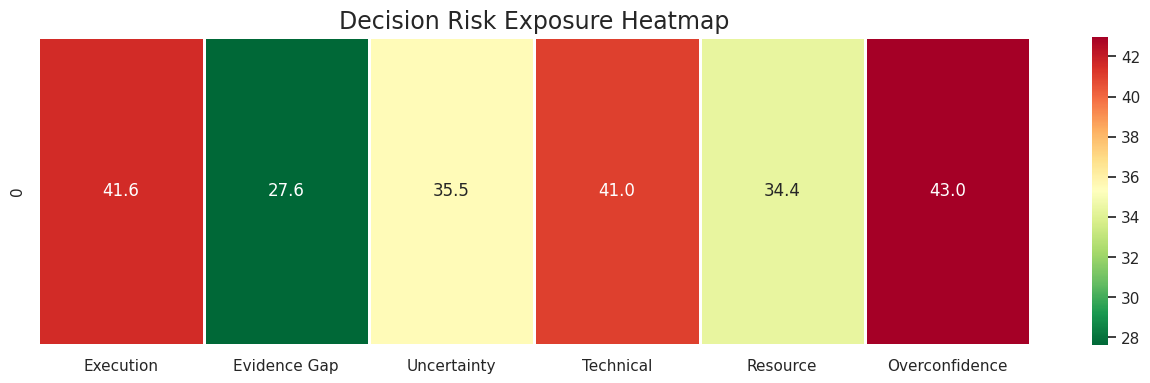

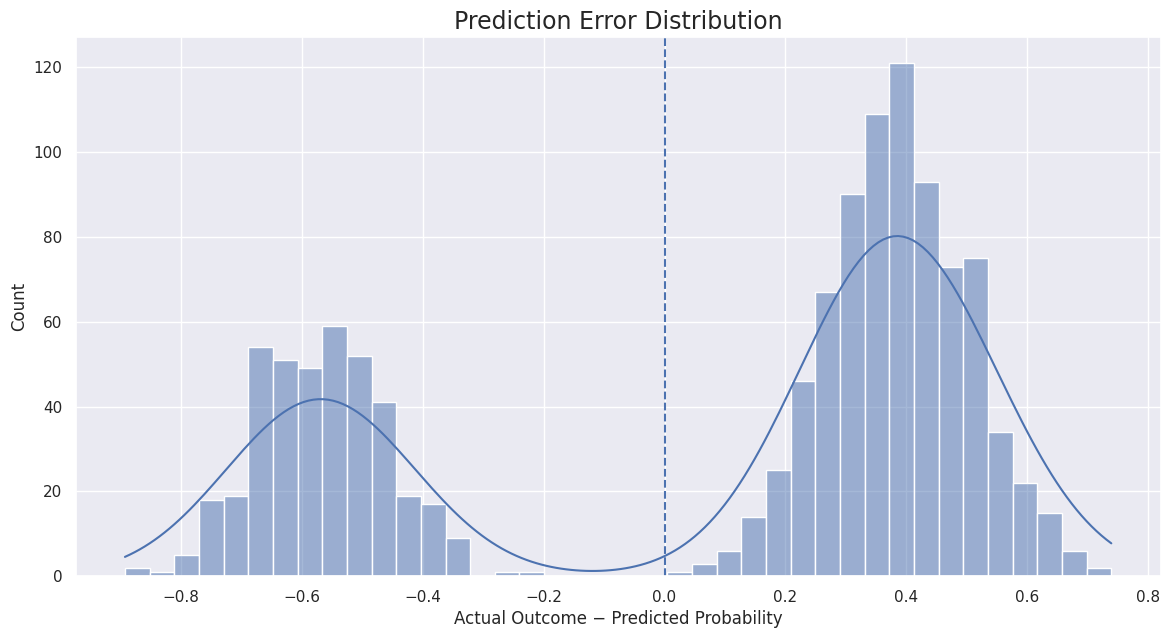

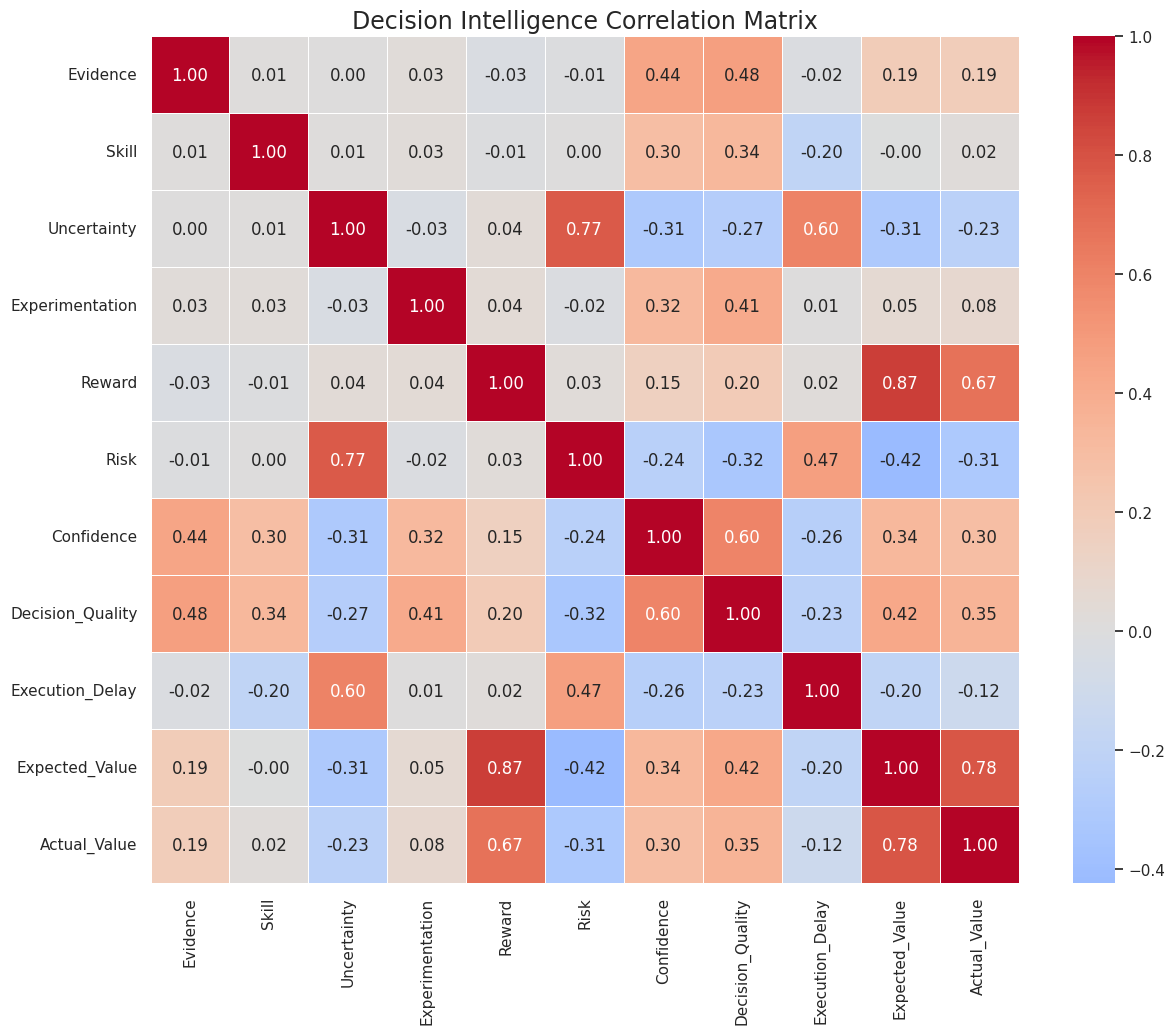

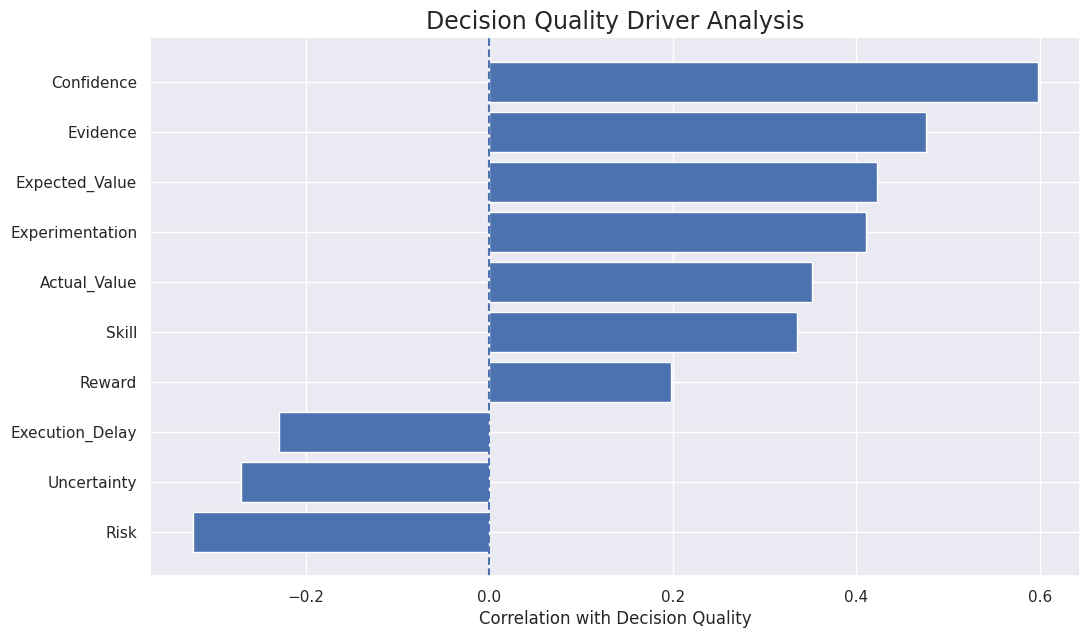

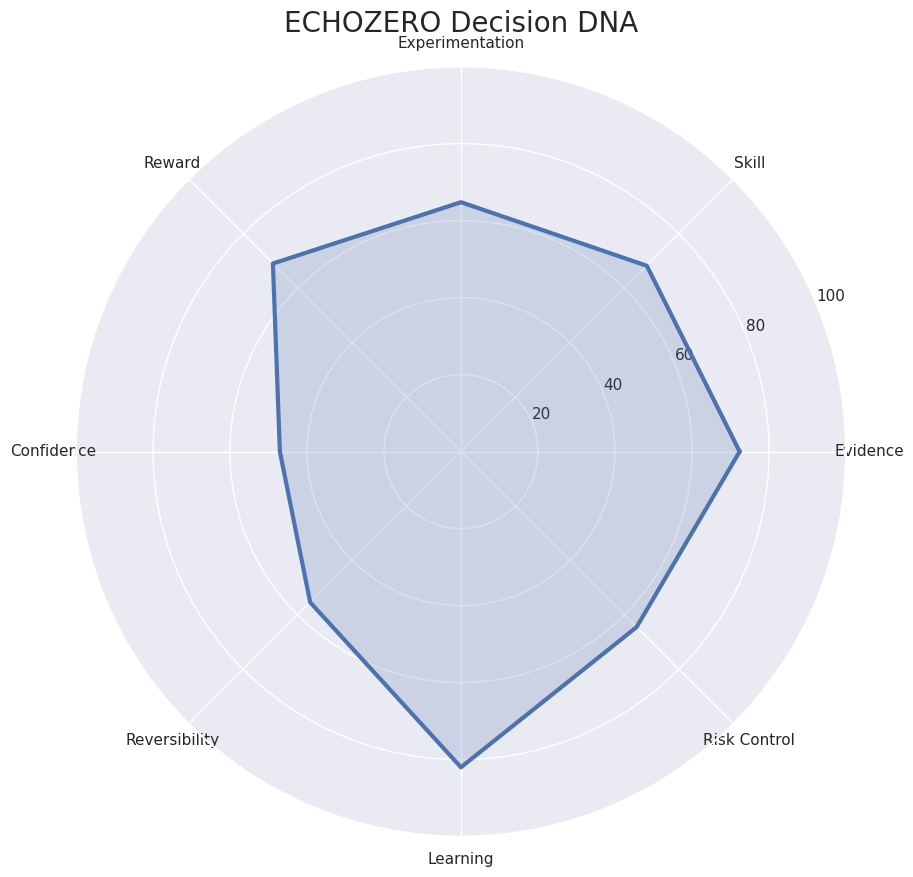

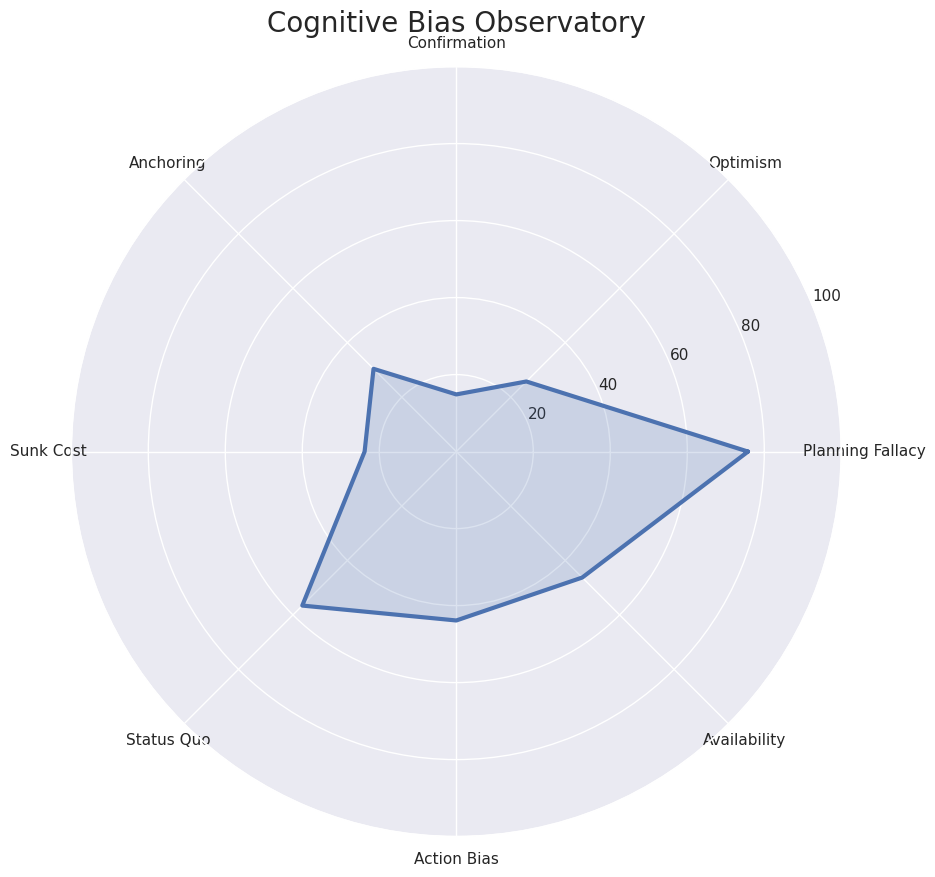


PCA explained variance: [0.28992476 0.20893706]


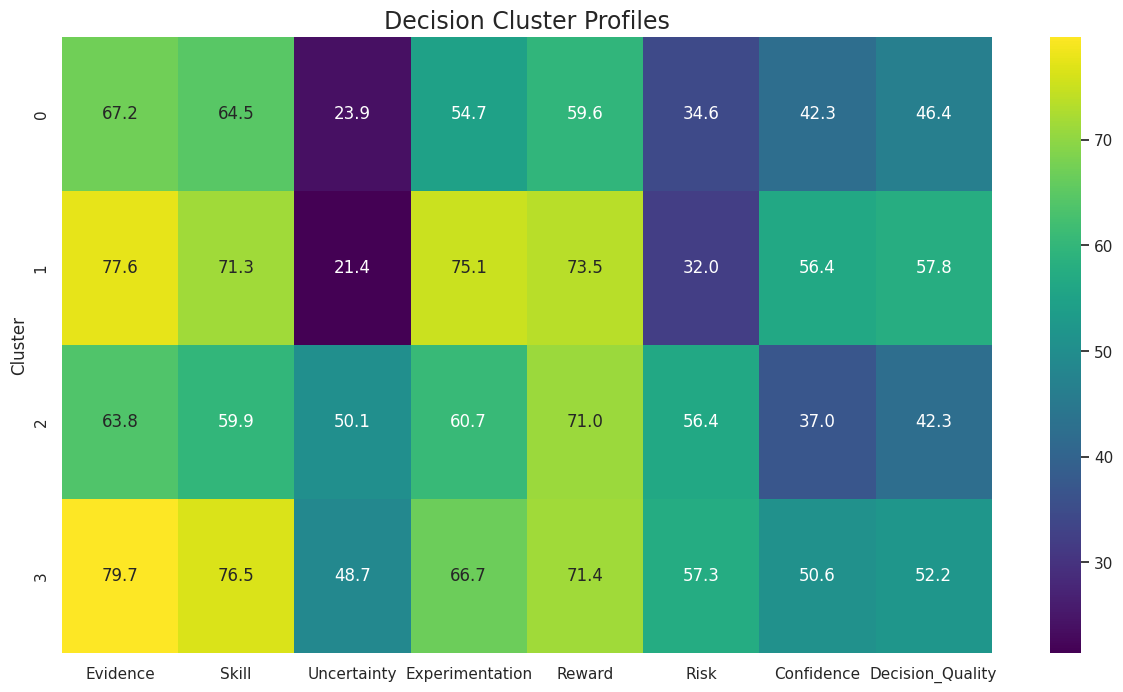



MONTE CARLO SIMULATION
P10: 56.27
P25: 74.42
P50: 95.79
P75: 116.77
P90: 135.69


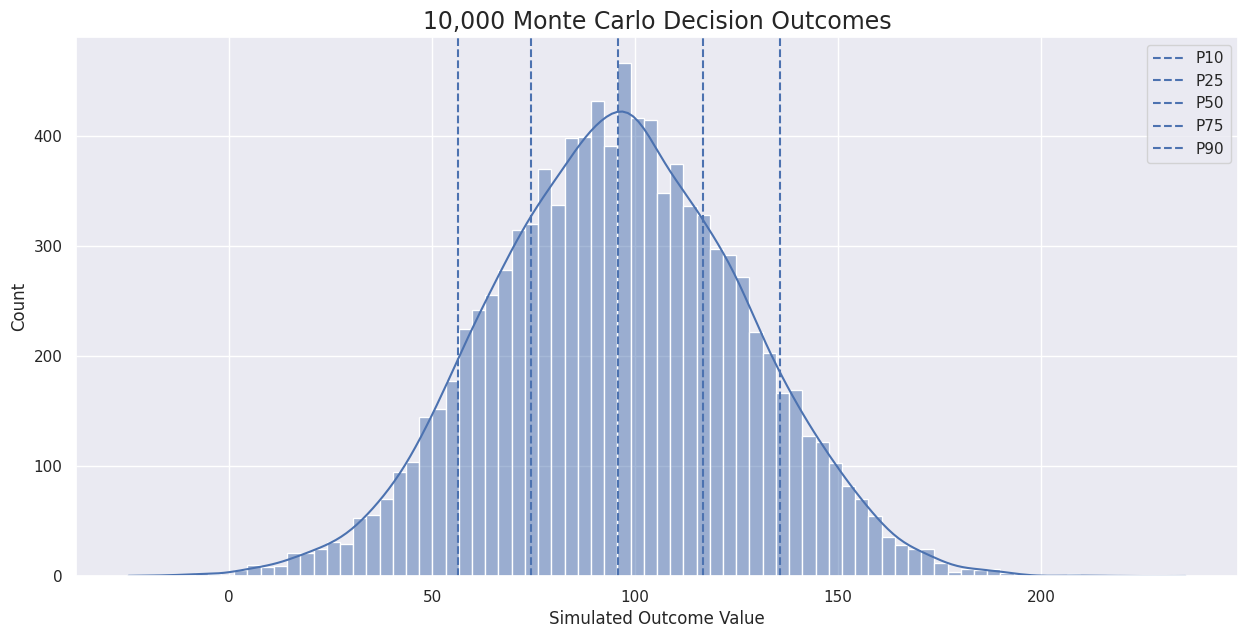

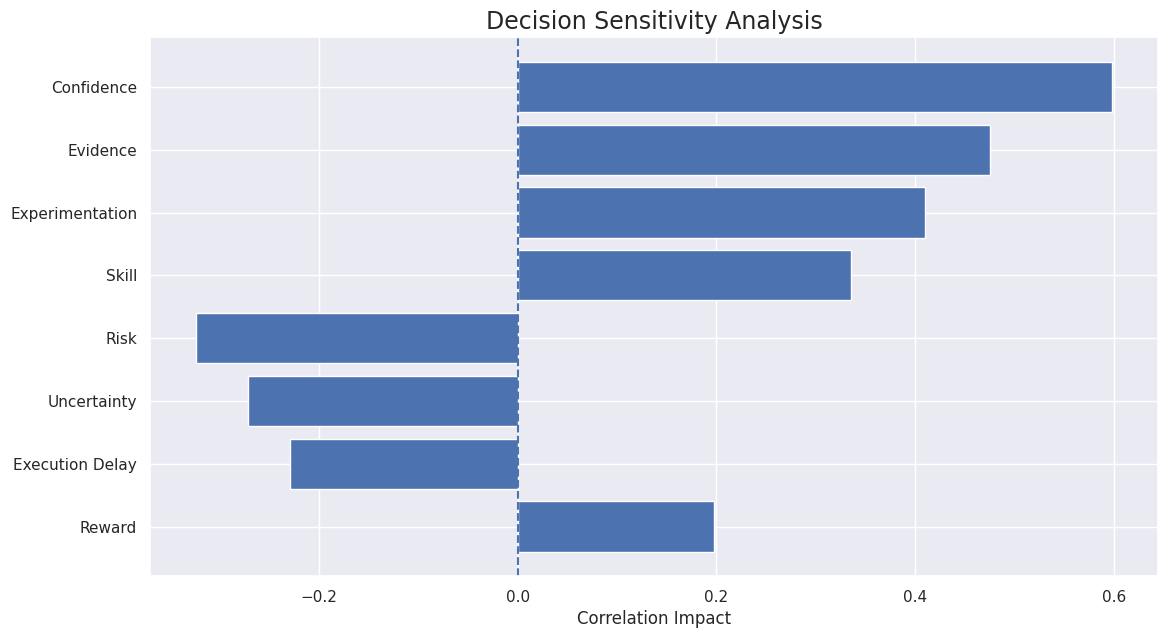


TOP RISKS
               Risk  Probability    Impact  Exposure
Resource Constraint    88.531964 60.519498 53.579101
  Technical Failure    54.065847 70.817134 38.287883
    Execution Delay    51.491929 64.689941 33.310099
        Timing Risk    55.540745 51.739793 28.736666
       Evidence Gap    52.047151 53.099817 27.636942
     Overconfidence    72.720730 33.784093 24.568039
 Market Uncertainty    32.735923 43.197204 14.141003
    Scope Expansion    45.213981 24.647355 11.144050
     External Shock    37.555852 28.359595 10.650687
      Adoption Risk    31.664109 33.411227 10.579368



DECISION MATRIX
Alternative  Evidence  Risk  Reward  Speed  Reversibility  Decision_Score
 Experiment        91    26      84     78             96           64.05
      Delay        79    31      51     92             90           51.65
        Buy        70    44      69     87             73           49.75
      Build        84    66      92     55             38           47.45
    Partner        66    53      76     65             58           44.25


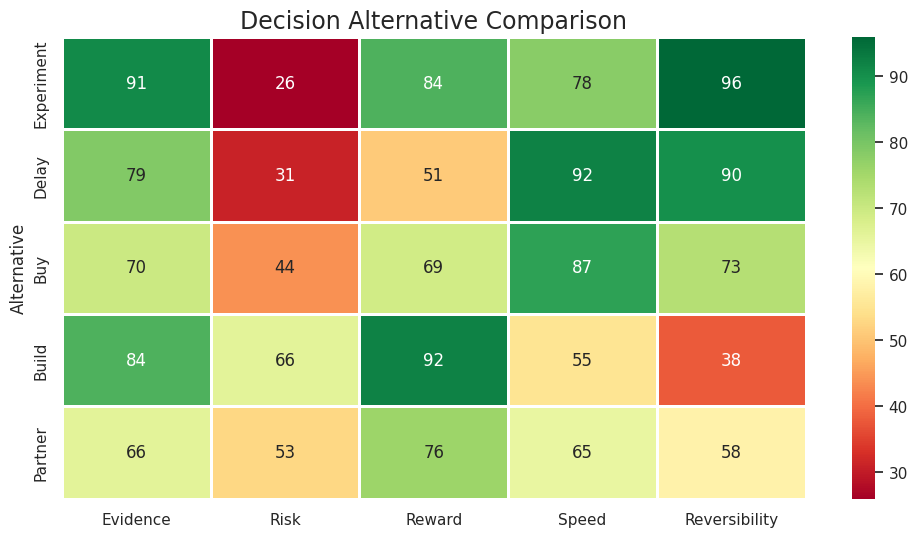


ECHOZERO — EXECUTIVE DECISION REPORT

DECISION HEALTH: 50.01%
CONFIDENCE: 47.04%
EVIDENCE: 72.38%
RISK LOAD: 44.61%
PREDICTION ACCURACY: 63.33%

RECOMMENDED OPTION: Experiment
DECISION SCORE: 64.05

HIGHEST RISK: Resource Constraint
RISK EXPOSURE: 53.58

STRONGEST DECISION DRIVER: Skill
DRIVER IMPACT: 0.335

BEST NEXT EXPERIMENT: Market Survey
EXPERIMENT VALUE/EFFORT: 4.918

RECOMMENDATION:
Use a reversible experiment to reduce uncertainty before making a high-cost irreversible decision.

FILES CREATED:
✓ echozero_decision_dataset.csv
✓ echozero_decision_matrix.csv
✓ echozero_risk_analysis.csv
✓ echozero_experiment_lab.csv
✓ echozero_cluster_profiles.csv

 ECHOZERO ANALYSIS COMPLETE


In [6]:
# ================================================================
# ECHOZERO — DECISION INTELLIGENCE ANALYTICS
# COMPLETE PYTHON + VISUALIZATION — ONE GOOGLE COLAB CELL
# ================================================================

# =========================
# 1. INSTALL / IMPORT
# =========================

import sys
import subprocess
import warnings

warnings.filterwarnings("ignore")

packages = [
    "numpy",
    "pandas",
    "matplotlib",
    "seaborn",
    "plotly",
    "scikit-learn",
    "networkx"
]

for package in packages:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", package],
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL
    )

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import networkx as nx

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    confusion_matrix
)

print("=" * 75)
print("ECHOZERO — DECISION INTELLIGENCE ENGINE")
print("=" * 75)


# ================================================================
# 2. GLOBAL VISUAL STYLE
# ================================================================

sns.set_theme(
    style="darkgrid",
    context="notebook"
)

plt.rcParams["figure.figsize"] = (
    14,
    7
)

plt.rcParams["axes.titlesize"] = 17
plt.rcParams["axes.labelsize"] = 12


# ================================================================
# 3. GENERATE REALISTIC DECISION DATA
# ================================================================

np.random.seed(42)

N = 1200

dates = pd.date_range(
    start="2023-01-01",
    periods=N,
    freq="D"
)

evidence = np.clip(
    np.random.normal(72, 15, N),
    5,
    100
)

skill = np.clip(
    np.random.normal(68, 16, N),
    5,
    100
)

uncertainty = np.clip(
    np.random.normal(35, 18, N),
    1,
    100
)

experimentation = np.clip(
    np.random.normal(66, 18, N),
    0,
    100
)

reward = np.clip(
    np.random.normal(70, 17, N),
    0,
    100
)

risk = np.clip(
    uncertainty * 0.70 +
    np.random.normal(20, 10, N),
    0,
    100
)

confidence = np.clip(
    evidence * 0.32 +
    skill * 0.18 +
    experimentation * 0.18 +
    reward * 0.10 -
    uncertainty * 0.20 +
    np.random.normal(0, 7, N),
    1,
    99
)


# ================================================================
# 4. TRUE SUCCESS PROBABILITY
# ================================================================

true_probability = np.clip(
    (
        evidence * 0.0035 +
        skill * 0.0025 +
        experimentation * 0.003 +
        reward * 0.002 -
        uncertainty * 0.002
    )
    +
    np.random.normal(0, 0.07, N),
    0.02,
    0.98
)


# ================================================================
# 5. MODEL PREDICTIONS
# ================================================================

predicted_probability = np.clip(
    true_probability
    +
    (
        confidence / 100 -
        true_probability
    ) * 0.40
    +
    np.random.normal(0, 0.06, N),
    0.01,
    0.99
)


# ================================================================
# 6. ACTUAL OUTCOMES
# ================================================================

outcome = np.random.binomial(
    1,
    true_probability
)


# ================================================================
# 7. DECISION QUALITY
# ================================================================

decision_quality = np.clip(
    evidence * 0.27
    +
    skill * 0.18
    +
    experimentation * 0.18
    +
    reward * 0.13
    +
    confidence * 0.12
    -
    risk * 0.18
    +
    np.random.normal(0, 6, N),
    0,
    100
)


# ================================================================
# 8. EXECUTION DELAY
# ================================================================

execution_delay = np.clip(
    40
    -
    skill * 0.10
    +
    uncertainty * 0.23
    +
    np.random.normal(0, 5, N),
    0,
    100
)


# ================================================================
# 9. EXPECTED VS ACTUAL VALUE
# ================================================================

expected_value = (
    reward * 1.45
    -
    risk * 0.75
    +
    evidence * 0.40
)

actual_value = (
    expected_value
    +
    outcome * 20
    +
    np.random.normal(0, 20, N)
)


# ================================================================
# 10. FINAL DATAFRAME
# ================================================================

df = pd.DataFrame({

    "Date": dates,

    "Evidence": evidence,

    "Skill": skill,

    "Uncertainty": uncertainty,

    "Experimentation": experimentation,

    "Reward": reward,

    "Risk": risk,

    "Confidence": confidence,

    "True_Probability": true_probability,

    "Predicted_Probability": predicted_probability,

    "Outcome": outcome,

    "Decision_Quality": decision_quality,

    "Execution_Delay": execution_delay,

    "Expected_Value": expected_value,

    "Actual_Value": actual_value

})

df["Prediction_Error"] = (
    df["Outcome"]
    -
    df["Predicted_Probability"]
)

df["Absolute_Error"] = (
    df["Prediction_Error"].abs()
)

df["Correct_Prediction"] = (
    (
        df["Predicted_Probability"] >= 0.5
    ).astype(int)
    ==
    df["Outcome"]
).astype(int)


# ================================================================
# 11. BASIC DATA AUDIT
# ================================================================

print("\nDATASET OVERVIEW")
print("-" * 75)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nData types:")
print(df.dtypes)


# ================================================================
# 12. KPI CALCULATIONS
# ================================================================

decision_health = df["Decision_Quality"].mean()

avg_confidence = df["Confidence"].mean()

evidence_score = df["Evidence"].mean()

risk_load = df["Risk"].mean()

accuracy = df["Correct_Prediction"].mean() * 100

mae = mean_absolute_error(
    df["Outcome"],
    df["Predicted_Probability"]
)

rmse = np.sqrt(
    mean_squared_error(
        df["Outcome"],
        df["Predicted_Probability"]
    )
)

success_probability = (
    df["True_Probability"].mean()
    *
    100
)

overconfidence = (
    df["Predicted_Probability"].mean()
    -
    df["Outcome"].mean()
) * 100


print("\n")
print("=" * 75)
print("EXECUTIVE KPIs")
print("=" * 75)

print(
    f"Decision Health       : {decision_health:.2f}%"
)

print(
    f"Average Confidence    : {avg_confidence:.2f}%"
)

print(
    f"Evidence Strength     : {evidence_score:.2f}%"
)

print(
    f"Risk Load             : {risk_load:.2f}%"
)

print(
    f"Prediction Accuracy   : {accuracy:.2f}%"
)

print(
    f"MAE                   : {mae:.4f}"
)

print(
    f"RMSE                  : {rmse:.4f}"
)

print(
    f"Success Probability   : {success_probability:.2f}%"
)

print(
    f"Overconfidence        : {overconfidence:+.2f}%"
)


# ================================================================
# 13. VISUALIZATION 1
# EXECUTIVE KPI DASHBOARD
# ================================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 10)
)

kpi_names = [
    "Decision Health",
    "Confidence",
    "Evidence",
    "Risk Load",
    "Accuracy",
    "Success Probability"
]

kpi_values = [
    decision_health,
    avg_confidence,
    evidence_score,
    risk_load,
    accuracy,
    success_probability
]

for ax, name, value in zip(
    axes.flatten(),
    kpi_names,
    kpi_values
):

    ax.barh(
        [name],
        [value]
    )

    ax.set_xlim(
        0,
        100
    )

    ax.set_title(
        name,
        fontweight="bold"
    )

    ax.text(
        value,
        0,
        f" {value:.1f}%",
        va="center",
        fontweight="bold"
    )

plt.suptitle(
    "ECHOZERO — Executive Intelligence Dashboard",
    fontsize=22,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# ================================================================
# 14. VISUALIZATION 2
# DECISION QUALITY TIMELINE
# ================================================================

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=df["Date"],
        y=df["Decision_Quality"],
        mode="lines",
        name="Decision Quality"
    )
)

fig.add_trace(
    go.Scatter(
        x=df["Date"],
        y=df["Confidence"],
        mode="lines",
        name="Confidence"
    )
)

fig.add_trace(
    go.Scatter(
        x=df["Date"],
        y=df["Evidence"],
        mode="lines",
        name="Evidence"
    )
)

fig.update_layout(
    title="Decision Intelligence Over Time",
    xaxis_title="Date",
    yaxis_title="Score",
    template="plotly_dark",
    height=600
)

fig.show()


# ================================================================
# 15. VISUALIZATION 3
# RISK HEATMAP
# ================================================================

risk_matrix = pd.DataFrame({

    "Execution": [
        df["Execution_Delay"].mean()
    ],

    "Evidence Gap": [
        100 - df["Evidence"].mean()
    ],

    "Uncertainty": [
        df["Uncertainty"].mean()
    ],

    "Technical": [
        df["Risk"].mean() * 0.92
    ],

    "Resource": [
        df["Risk"].mean() * 0.77
    ],

    "Overconfidence": [
        max(
            0,
            overconfidence + 50
        )
    ]

})

plt.figure(
    figsize=(16, 4)
)

sns.heatmap(
    risk_matrix,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn_r",
    linewidths=1
)

plt.title(
    "Decision Risk Exposure Heatmap"
)

plt.show()


# ================================================================
# 16. VISUALIZATION 4
# RISK × REWARD
# ================================================================

fig = px.scatter(
    df.sample(
        min(700, len(df)),
        random_state=42
    ),
    x="Risk",
    y="Reward",
    size="Evidence",
    color="Decision_Quality",
    hover_data=[
        "Confidence",
        "Uncertainty",
        "Experimentation"
    ],
    title="Risk × Reward Opportunity Map",
    template="plotly_dark"
)

fig.update_layout(
    height=650
)

fig.show()


# ================================================================
# 17. VISUALIZATION 5
# EVIDENCE VS CONFIDENCE
# ================================================================

fig = px.scatter(
    df.sample(
        min(700, len(df)),
        random_state=10
    ),
    x="Evidence",
    y="Confidence",
    size="Decision_Quality",
    color="Risk",
    hover_data=[
        "Reward",
        "Uncertainty",
        "Experimentation"
    ],
    title="Evidence Strength vs Decision Confidence",
    template="plotly_dark"
)

fig.show()


# ================================================================
# 18. VISUALIZATION 6
# CONFIDENCE VS REALITY
# ================================================================

fig = px.scatter(
    df.sample(
        min(700, len(df)),
        random_state=11
    ),
    x="Predicted_Probability",
    y="Outcome",
    color="Prediction_Error",
    size="Confidence",
    title="Prediction vs Reality",
    template="plotly_dark"
)

fig.add_trace(
    go.Scatter(
        x=[0, 1],
        y=[0, 1],
        mode="lines",
        name="Perfect Prediction"
    )
)

fig.show()


# ================================================================
# 19. VISUALIZATION 7
# PREDICTION ERROR DISTRIBUTION
# ================================================================

plt.figure(
    figsize=(14, 7)
)

sns.histplot(
    df["Prediction_Error"],
    bins=40,
    kde=True
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title(
    "Prediction Error Distribution"
)

plt.xlabel(
    "Actual Outcome − Predicted Probability"
)

plt.show()


# ================================================================
# 20. VISUALIZATION 8
# CONFIDENCE CALIBRATION CURVE
# ================================================================

bins = np.linspace(
    0,
    1,
    11
)

calibration = []

for i in range(
    len(bins) - 1
):

    mask = (
        (df["Predicted_Probability"] >= bins[i])
        &
        (df["Predicted_Probability"] < bins[i + 1])
    )

    if mask.sum() > 0:

        calibration.append({

            "Predicted":
                (
                    bins[i]
                    +
                    bins[i + 1]
                ) / 2,

            "Observed":
                df.loc[
                    mask,
                    "Outcome"
                ].mean()

        })

calibration = pd.DataFrame(
    calibration
)

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=calibration["Predicted"],
        y=calibration["Observed"],
        mode="lines+markers",
        name="Model"
    )
)

fig.add_trace(
    go.Scatter(
        x=[0, 1],
        y=[0, 1],
        mode="lines",
        name="Perfect Calibration",
        line=dict(
            dash="dash"
        )
    )
)

fig.update_layout(
    title="Confidence Calibration Curve",
    xaxis_title="Predicted Probability",
    yaxis_title="Observed Probability",
    template="plotly_dark"
)

fig.show()


# ================================================================
# 21. VISUALIZATION 9
# FEATURE CORRELATION MATRIX
# ================================================================

feature_columns = [
    "Evidence",
    "Skill",
    "Uncertainty",
    "Experimentation",
    "Reward",
    "Risk",
    "Confidence",
    "Decision_Quality",
    "Execution_Delay",
    "Expected_Value",
    "Actual_Value"
]

corr = df[
    feature_columns
].corr()

plt.figure(
    figsize=(14, 11)
)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title(
    "Decision Intelligence Correlation Matrix"
)

plt.show()


# ================================================================
# 22. VISUALIZATION 10
# DECISION DRIVER IMPORTANCE
# ================================================================

correlations = (
    df[
        feature_columns
    ]
    .corr()["Decision_Quality"]
    .drop("Decision_Quality")
    .sort_values()
)

plt.figure(
    figsize=(12, 7)
)

plt.barh(
    correlations.index,
    correlations.values
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title(
    "Decision Quality Driver Analysis"
)

plt.xlabel(
    "Correlation with Decision Quality"
)

plt.show()


# ================================================================
# 23. VISUALIZATION 11
# DECISION DNA RADAR
# ================================================================

dna_categories = [
    "Evidence",
    "Skill",
    "Experimentation",
    "Reward",
    "Confidence",
    "Reversibility",
    "Learning",
    "Risk Control"
]

dna_values = [
    df["Evidence"].mean(),
    df["Skill"].mean(),
    df["Experimentation"].mean(),
    df["Reward"].mean(),
    df["Confidence"].mean(),
    100 - df["Risk"].mean(),
    82,
    100 - df["Uncertainty"].mean()
]

angles = np.linspace(
    0,
    2 * np.pi,
    len(dna_categories),
    endpoint=False
)

angles = np.concatenate(
    [angles, [angles[0]]]
)

values = np.concatenate(
    [dna_values, [dna_values[0]]]
)

fig = plt.figure(
    figsize=(10, 10)
)

ax = fig.add_subplot(
    111,
    polar=True
)

ax.plot(
    angles,
    values,
    linewidth=3
)

ax.fill(
    angles,
    values,
    alpha=0.20
)

ax.set_xticks(
    angles[:-1]
)

ax.set_xticklabels(
    dna_categories
)

ax.set_ylim(
    0,
    100
)

ax.set_title(
    "ECHOZERO Decision DNA",
    pad=25,
    fontsize=20
)

plt.show()


# ================================================================
# 24. VISUALIZATION 12
# COGNITIVE BIAS RADAR
# ================================================================

bias_names = [
    "Planning Fallacy",
    "Optimism",
    "Confirmation",
    "Anchoring",
    "Sunk Cost",
    "Status Quo",
    "Action Bias",
    "Availability"
]

bias_values = np.clip(
    np.random.normal(
        50,
        17,
        len(bias_names)
    ),
    5,
    95
)

angles = np.linspace(
    0,
    2 * np.pi,
    len(bias_names),
    endpoint=False
)

angles = np.concatenate(
    [angles, [angles[0]]]
)

bias_values = np.concatenate(
    [bias_values, [bias_values[0]]]
)

fig = plt.figure(
    figsize=(10, 10)
)

ax = fig.add_subplot(
    111,
    polar=True
)

ax.plot(
    angles,
    bias_values,
    linewidth=3
)

ax.fill(
    angles,
    bias_values,
    alpha=0.20
)

ax.set_xticks(
    angles[:-1]
)

ax.set_xticklabels(
    bias_names
)

ax.set_ylim(
    0,
    100
)

ax.set_title(
    "Cognitive Bias Observatory",
    pad=25,
    fontsize=20
)

plt.show()


# ================================================================
# 25. VISUALIZATION 13
# PCA DECISION SPACE
# ================================================================

X = df[
    [
        "Evidence",
        "Skill",
        "Uncertainty",
        "Experimentation",
        "Reward",
        "Risk",
        "Confidence"
    ]
]

X_scaled = StandardScaler().fit_transform(
    X
)

pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

pca_df = pd.DataFrame({

    "PC1": X_pca[:, 0],

    "PC2": X_pca[:, 1],

    "Decision_Quality":
        df["Decision_Quality"].values,

    "Outcome":
        df["Outcome"].values

})

fig = px.scatter(
    pca_df,
    x="PC1",
    y="PC2",
    color="Decision_Quality",
    symbol="Outcome",
    title="Decision Intelligence — PCA Space",
    template="plotly_dark"
)

fig.show()

print(
    "\nPCA explained variance:",
    pca.explained_variance_ratio_
)


# ================================================================
# 26. VISUALIZATION 14
# DECISION CLUSTERS
# ================================================================

cluster_model = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = cluster_model.fit_predict(
    X_scaled
)

cluster_df = df.copy()

cluster_df["Cluster"] = clusters.astype(str)

fig = px.scatter(
    cluster_df.sample(
        min(800, len(cluster_df)),
        random_state=20
    ),
    x="Evidence",
    y="Decision_Quality",
    color="Cluster",
    size="Confidence",
    hover_data=[
        "Risk",
        "Reward",
        "Uncertainty"
    ],
    title="Decision Behavior Clusters",
    template="plotly_dark"
)

fig.show()


# ================================================================
# 27. CLUSTER PROFILE
# ================================================================

cluster_profile = (
    cluster_df
    .groupby("Cluster")[
        [
            "Evidence",
            "Skill",
            "Uncertainty",
            "Experimentation",
            "Reward",
            "Risk",
            "Confidence",
            "Decision_Quality"
        ]
    ]
    .mean()
)

plt.figure(
    figsize=(15, 8)
)

sns.heatmap(
    cluster_profile,
    annot=True,
    fmt=".1f",
    cmap="viridis"
)

plt.title(
    "Decision Cluster Profiles"
)

plt.show()


# ================================================================
# 28. MONTE CARLO SIMULATION
# ================================================================

print("\n")
print("=" * 75)
print("MONTE CARLO SIMULATION")
print("=" * 75)

SIMULATIONS = 10000

simulation_mean = df[
    "Expected_Value"
].mean()

simulation_std = max(
    10,
    df["Risk"].mean() * 0.70
)

simulation_values = np.random.normal(
    simulation_mean,
    simulation_std,
    SIMULATIONS
)

percentiles = {

    "P10":
        np.percentile(
            simulation_values,
            10
        ),

    "P25":
        np.percentile(
            simulation_values,
            25
        ),

    "P50":
        np.percentile(
            simulation_values,
            50
        ),

    "P75":
        np.percentile(
            simulation_values,
            75
        ),

    "P90":
        np.percentile(
            simulation_values,
            90
        )
}

for key, value in percentiles.items():

    print(
        f"{key}: {value:.2f}"
    )


# ================================================================
# 29. MONTE CARLO HISTOGRAM
# ================================================================

plt.figure(
    figsize=(15, 7)
)

sns.histplot(
    simulation_values,
    bins=80,
    kde=True
)

for key, value in percentiles.items():

    plt.axvline(
        value,
        linestyle="--",
        label=key
    )

plt.title(
    "10,000 Monte Carlo Decision Outcomes"
)

plt.xlabel(
    "Simulated Outcome Value"
)

plt.legend()

plt.show()


# ================================================================
# 30. CUMULATIVE DISTRIBUTION
# ================================================================

sorted_values = np.sort(
    simulation_values
)

cdf = np.arange(
    1,
    len(sorted_values) + 1
) / len(sorted_values)

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=sorted_values,
        y=cdf,
        mode="lines",
        name="CDF"
    )
)

fig.update_layout(
    title="Cumulative Probability Distribution",
    xaxis_title="Outcome Value",
    yaxis_title="Probability",
    template="plotly_dark"
)

fig.show()


# ================================================================
# 31. SENSITIVITY ANALYSIS
# ================================================================

sensitivity = pd.DataFrame({

    "Feature": [
        "Evidence",
        "Skill",
        "Experimentation",
        "Reward",
        "Confidence",
        "Uncertainty",
        "Risk",
        "Execution Delay"
    ],

    "Impact": [

        df["Evidence"].corr(
            df["Decision_Quality"]
        ),

        df["Skill"].corr(
            df["Decision_Quality"]
        ),

        df["Experimentation"].corr(
            df["Decision_Quality"]
        ),

        df["Reward"].corr(
            df["Decision_Quality"]
        ),

        df["Confidence"].corr(
            df["Decision_Quality"]
        ),

        df["Uncertainty"].corr(
            df["Decision_Quality"]
        ),

        df["Risk"].corr(
            df["Decision_Quality"]
        ),

        df["Execution_Delay"].corr(
            df["Decision_Quality"]
        )
    ]
})

sensitivity["Absolute"] = (
    sensitivity["Impact"].abs()
)

sensitivity = sensitivity.sort_values(
    "Absolute"
)

plt.figure(
    figsize=(13, 7)
)

plt.barh(
    sensitivity["Feature"],
    sensitivity["Impact"]
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title(
    "Decision Sensitivity Analysis"
)

plt.xlabel(
    "Correlation Impact"
)

plt.show()


# ================================================================
# 32. RISK EXPOSURE MODEL
# ================================================================

risk_names = [
    "Execution Delay",
    "Evidence Gap",
    "Market Uncertainty",
    "Technical Failure",
    "Resource Constraint",
    "Overconfidence",
    "Scope Expansion",
    "Timing Risk",
    "Adoption Risk",
    "External Shock"
]

risk_probability = np.clip(
    np.random.normal(
        55,
        18,
        len(risk_names)
    ),
    5,
    95
)

risk_impact = np.clip(
    np.random.normal(
        62,
        18,
        len(risk_names)
    ),
    5,
    100
)

risk_df = pd.DataFrame({

    "Risk": risk_names,

    "Probability":
        risk_probability,

    "Impact":
        risk_impact
})

risk_df["Exposure"] = (
    risk_df["Probability"]
    *
    risk_df["Impact"]
    /
    100
)

risk_df = risk_df.sort_values(
    "Exposure",
    ascending=False
)

print("\nTOP RISKS")
print(
    risk_df.head(10).to_string(
        index=False
    )
)


# ================================================================
# 33. RISK EXPOSURE VISUALIZATION
# ================================================================

fig = px.scatter(
    risk_df,
    x="Probability",
    y="Impact",
    size="Exposure",
    color="Exposure",
    text="Risk",
    title="Risk Probability × Impact Observatory",
    template="plotly_dark"
)

fig.update_traces(
    textposition="top center"
)

fig.show()


# ================================================================
# 34. RISK RANKING
# ================================================================

fig = px.bar(
    risk_df,
    x="Exposure",
    y="Risk",
    orientation="h",
    color="Exposure",
    title="Risk Exposure Ranking",
    template="plotly_dark"
)

fig.show()


# ================================================================
# 35. EXPERIMENT LAB
# ================================================================

experiment_names = [
    "Landing Page Test",
    "Pricing Test",
    "Prototype Test",
    "User Interview",
    "A/B Experiment",
    "Technical Spike",
    "Market Survey",
    "Feature Prototype",
    "Retention Test",
    "Performance Benchmark"
]

experiment_df = pd.DataFrame({

    "Experiment":
        experiment_names,

    "Effort":
        np.random.uniform(
            10,
            90,
            len(experiment_names)
        ),

    "Impact":
        np.random.uniform(
            30,
            100,
            len(experiment_names)
        ),

    "Confidence":
        np.random.uniform(
            40,
            95,
            len(experiment_names)
        )
})

experiment_df["Value_per_Effort"] = (
    experiment_df["Impact"]
    /
    experiment_df["Effort"]
)

experiment_df = experiment_df.sort_values(
    "Value_per_Effort",
    ascending=False
)

fig = px.scatter(
    experiment_df,
    x="Effort",
    y="Impact",
    size="Confidence",
    color="Value_per_Effort",
    text="Experiment",
    title="Experiment Opportunity Map",
    template="plotly_dark"
)

fig.update_traces(
    textposition="top center"
)

fig.show()


# ================================================================
# 36. DECISION KNOWLEDGE GRAPH
# ================================================================

G = nx.Graph()

nodes = [
    "Decision",
    "Evidence",
    "Assumptions",
    "Risks",
    "Options",
    "Experiments",
    "Outcomes",
    "Learning"
]

edges = [

    ("Decision", "Evidence"),

    ("Decision", "Assumptions"),

    ("Decision", "Risks"),

    ("Decision", "Options"),

    ("Evidence", "Assumptions"),

    ("Evidence", "Options"),

    ("Assumptions", "Risks"),

    ("Options", "Experiments"),

    ("Experiments", "Outcomes"),

    ("Outcomes", "Learning"),

    ("Learning", "Evidence")

]

G.add_nodes_from(
    nodes
)

G.add_edges_from(
    edges
)

pos = nx.spring_layout(
    G,
    seed=42,
    k=2
)

edge_x = []
edge_y = []

for source, target in G.edges():

    x0, y0 = pos[source]

    x1, y1 = pos[target]

    edge_x.extend(
        [x0, x1, None]
    )

    edge_y.extend(
        [y0, y1, None]
    )

node_x = []
node_y = []

for node in G.nodes():

    x, y = pos[node]

    node_x.append(x)
    node_y.append(y)

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=edge_x,
        y=edge_y,
        mode="lines",
        line=dict(
            width=1
        ),
        hoverinfo="none"
    )
)

fig.add_trace(
    go.Scatter(
        x=node_x,
        y=node_y,
        mode="markers+text",
        text=list(G.nodes()),
        textposition="middle center",
        marker=dict(
            size=55
        )
    )
)

fig.update_layout(
    title="ECHOZERO Decision Knowledge Graph",
    showlegend=False,
    xaxis=dict(
        visible=False
    ),
    yaxis=dict(
        visible=False
    ),
    template="plotly_dark",
    height=700
)

fig.show()


# ================================================================
# 37. DECISION TIMELINE
# ================================================================

timeline = pd.DataFrame({

    "Stage": [
        "Question",
        "Evidence",
        "Assumption",
        "Prediction",
        "Decision",
        "Experiment",
        "Outcome",
        "Learning"
    ],

    "Confidence": [
        30,
        52,
        48,
        65,
        74,
        82,
        88,
        94
    ],

    "Date": pd.date_range(
        "2024-01-01",
        periods=8,
        freq="30D"
    )
})

fig = px.line(
    timeline,
    x="Date",
    y="Confidence",
    markers=True,
    text="Stage",
    title="Decision Lifecycle Timeline",
    template="plotly_dark"
)

fig.update_traces(
    textposition="top center"
)

fig.show()


# ================================================================
# 38. DECISION MATRIX
# ================================================================

alternatives = pd.DataFrame({

    "Alternative": [
        "Build",
        "Buy",
        "Partner",
        "Delay",
        "Experiment"
    ],

    "Evidence": [
        84,
        70,
        66,
        79,
        91
    ],

    "Risk": [
        66,
        44,
        53,
        31,
        26
    ],

    "Reward": [
        92,
        69,
        76,
        51,
        84
    ],

    "Speed": [
        55,
        87,
        65,
        92,
        78
    ],

    "Reversibility": [
        38,
        73,
        58,
        90,
        96
    ]
})

alternatives["Decision_Score"] = (

    alternatives["Evidence"] * 0.25

    +

    alternatives["Reward"] * 0.30

    +

    alternatives["Speed"] * 0.15

    +

    alternatives["Reversibility"] * 0.10

    -

    alternatives["Risk"] * 0.20

)

alternatives = alternatives.sort_values(
    "Decision_Score",
    ascending=False
)

print("\nDECISION MATRIX")
print(
    alternatives.to_string(
        index=False
    )
)


# ================================================================
# 39. DECISION MATRIX HEATMAP
# ================================================================

matrix = alternatives.set_index(
    "Alternative"
)[
    [
        "Evidence",
        "Risk",
        "Reward",
        "Speed",
        "Reversibility"
    ]
]

plt.figure(
    figsize=(12, 6)
)

sns.heatmap(
    matrix,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn",
    linewidths=1
)

plt.title(
    "Decision Alternative Comparison"
)

plt.show()


# ================================================================
# 40. FINAL DECISION INTELLIGENCE REPORT
# ================================================================

best_option = alternatives.iloc[0]

highest_risk = risk_df.iloc[0]

highest_driver = sensitivity.iloc[
    sensitivity["Absolute"].idxmax()
]

best_experiment = experiment_df.iloc[0]


print()
print("=" * 75)
print("ECHOZERO — EXECUTIVE DECISION REPORT")
print("=" * 75)

print()

print(
    "DECISION HEALTH:",
    f"{decision_health:.2f}%"
)

print(
    "CONFIDENCE:",
    f"{avg_confidence:.2f}%"
)

print(
    "EVIDENCE:",
    f"{evidence_score:.2f}%"
)

print(
    "RISK LOAD:",
    f"{risk_load:.2f}%"
)

print(
    "PREDICTION ACCURACY:",
    f"{accuracy:.2f}%"
)

print()

print(
    "RECOMMENDED OPTION:",
    best_option["Alternative"]
)

print(
    "DECISION SCORE:",
    f"{best_option['Decision_Score']:.2f}"
)

print()

print(
    "HIGHEST RISK:",
    highest_risk["Risk"]
)

print(
    "RISK EXPOSURE:",
    f"{highest_risk['Exposure']:.2f}"
)

print()

print(
    "STRONGEST DECISION DRIVER:",
    highest_driver["Feature"]
)

print(
    "DRIVER IMPACT:",
    f"{highest_driver['Impact']:.3f}"
)

print()

print(
    "BEST NEXT EXPERIMENT:",
    best_experiment["Experiment"]
)

print(
    "EXPERIMENT VALUE/EFFORT:",
    f"{best_experiment['Value_per_Effort']:.3f}"
)

print()

print("=" * 75)

print(
    "RECOMMENDATION:"
)

print(
    "Use a reversible experiment to reduce uncertainty "
    "before making a high-cost irreversible decision."
)

print("=" * 75)


# ================================================================
# 41. SAVE COMPLETE DATA
# ================================================================

df.to_csv(
    "echozero_decision_dataset.csv",
    index=False
)

alternatives.to_csv(
    "echozero_decision_matrix.csv",
    index=False
)

risk_df.to_csv(
    "echozero_risk_analysis.csv",
    index=False
)

experiment_df.to_csv(
    "echozero_experiment_lab.csv",
    index=False
)

cluster_profile.to_csv(
    "echozero_cluster_profiles.csv"
)

print()
print("FILES CREATED:")
print("✓ echozero_decision_dataset.csv")
print("✓ echozero_decision_matrix.csv")
print("✓ echozero_risk_analysis.csv")
print("✓ echozero_experiment_lab.csv")
print("✓ echozero_cluster_profiles.csv")

print()
print("=" * 75)
print(" ECHOZERO ANALYSIS COMPLETE")
print("=" * 75)